Notebook for tuning the underlying linear algebra machinery.

In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [2]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [3]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 500
R_max = 500
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = 0.0 * np.random.rand(N_chamber)
y_nodes = 0.0 * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Characteristic node separation distance
node_sep = z_scale/(N_chamber - 1)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=None,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [5]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=1e2,#1e2,
                                   R_outer_ratio=20, max_edge_dist=1.1*node_sep)

# Source term due to mass injection at node 0
f_inj = global_sys.create_single_mass_injection_source(3.0)
# Source term due to eruption at node -1
f_erupt = global_sys.create_eruption_source(p_erupt=5e6, mu_erupt=1e5, r_conduit=25)

In [6]:
t_vec = np.linspace(0, .2e11, 400)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt, solve_full_matrix=False)
q_out_fs, m_erupted_out_fs = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt, solve_full_matrix=True)

In [7]:
if False:
  ''' Verify post-processing step '''
  # Extract masses, vectorized
  _m = q_out.squeeze()[:,global_sys.mass_indices]
  # Compute wall displacements
  _u = np.zeros((q_out.shape[0], global_sys.num_blocks,))

  _p = np.zeros_like(_u)

  for i in range(q_out.shape[0]):
    # Compute displacement time-by-time
    _u[i,:] = (global_sys.H0_global @ q_out.squeeze()[i,:]).ravel() + global_sys.k0_global
  for j, node in enumerate(global_sys.nodes):
    # Compute pressure node-by-node
    dp_u = -3 * global_sys.K_f * _u[:,j] / node.R0
    dp_m = global_sys.K_f * ((_m[:,j] - node.m0) / node.m0)
    _p[:,j] = node.p0 + dp_u + dp_m

  m, p, sigmas, u = global_sys.post_process(t_vec, q_out)

  np.max(m - _m.squeeze()), np.max(u[...,0] - _u.squeeze()), np.max(p - _p.squeeze())

In [8]:
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt, solve_full_matrix=False)


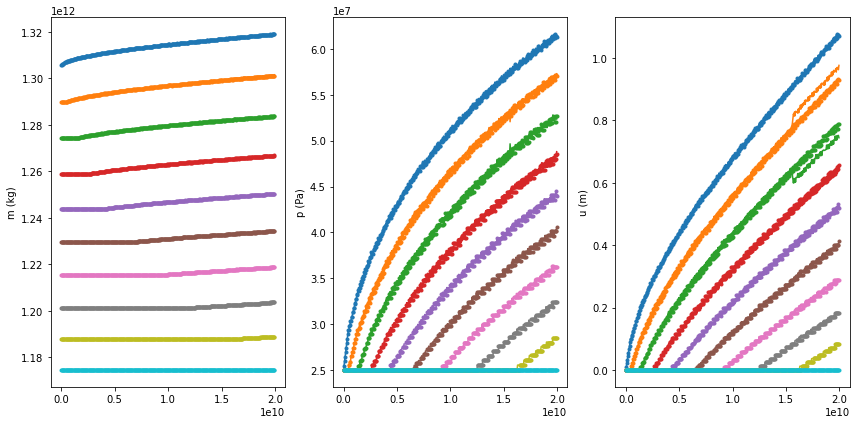

In [9]:
m, p, u = global_sys.compute_m_p_u(q_out_fs)
fig, ax = plt.subplots(1, 3, figsize=(12,6))

max_plot_index = -1
m, p, u = global_sys.compute_m_p_u(q_out_fs)
ax[0].plot(t_vec[:max_plot_index], m[:max_plot_index])
ax[1].plot(t_vec[:max_plot_index], p[:max_plot_index])
ax[2].plot(t_vec[:max_plot_index], u[:max_plot_index])

m, p, u = global_sys.compute_m_p_u(q_out)
ax[0].plot(t_vec[:max_plot_index], m[:max_plot_index], '.')
ax[1].plot(t_vec[:max_plot_index], p[:max_plot_index], '.')
ax[2].plot(t_vec[:max_plot_index], u[:max_plot_index], '.')
ax[0].set_ylabel("m (kg)")
ax[1].set_ylabel("p (Pa)")
ax[2].set_ylabel("u (m)")
fig.tight_layout()

In [10]:
np.all(q_out[0,:] == global_sys.q0.ravel()), \
  np.all(q_out_fs[0,:] == global_sys.q0.ravel()), 

(True, True)

In [11]:
q_out[0,:], q_out_fs[0,:]

(array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]))

-0.0006482055813022503

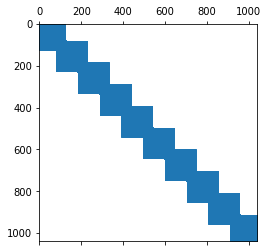

In [12]:
dt = t_vec[1] - t_vec[0]
L, M, f = global_sys.assemble_global_LMf(q_out[0,:])
static_factor = scipy.sparse.eye(global_sys.num_dof) + dt * L
static_inv = scipy.sparse.linalg.inv(scipy.sparse.csc_matrix(static_factor))

plt.spy(static_factor)

np.min(static_factor - static_factor.T)

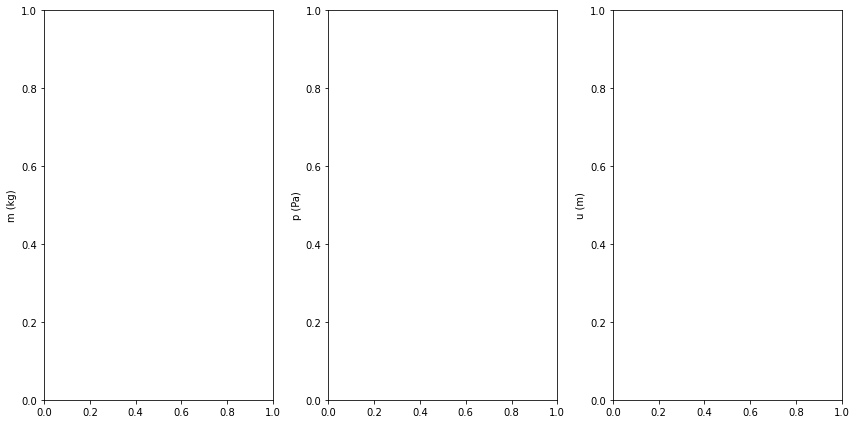

In [13]:
m, p, u = global_sys.compute_m_p_u(q_out)
fig, ax = plt.subplots(1, 3, figsize=(12,6))

max_plot_index = 10

ax[0].set_ylabel("m (kg)")
ax[1].set_ylabel("p (Pa)")
ax[2].set_ylabel("u (m)")
fig.tight_layout()

In [16]:
self = global_sys
L, M, f = self.assemble_global_LMf(global_sys.q0)
f = f.toarray()

# Inverse desired: inv(scipy.sparse.eye(global_sys.num_dof) + dt * L + dt * M)
dt = t_vec[1] - t_vec[0]
# Additive separation of LHS matrix
static_factor = scipy.sparse.eye(self.num_dof) + dt * L
# Compute sparse inverse of static part
static_inv = scipy.sparse.linalg.inv(scipy.sparse.csc_matrix(static_factor))

In [19]:
# Construct scaling for state vector
_scaling_vec = 0.01 * np.ones((self.num_dof))
for i, node in enumerate(self.nodes):
  _scaling_vec[self.mass_indices[i]] = node.m0

# Construct diagonal scaling matrix
_scaling_mat = scipy.sparse.spdiags(_scaling_vec, 0, self.num_dof, self.num_dof)
_scaling_mat_inv = scipy.sparse.spdiags(1/_scaling_vec, 0, self.num_dof, self.num_dof)

# To illustrate, compute condition number of scaled system, and unscaled system
unscaled_matrix = (scipy.sparse.eye(self.num_dof) + dt * M)
scaled_matrix = scipy.sparse.eye(self.num_dof) + (
  + dt * _scaling_mat_inv @ unscaled_matrix @ _scaling_mat)

In [20]:
# Pick target for comparison
t = 0.0
q = q_out[11,:,np.newaxis]

# Evaluate eruption rate
vec_f_erupt = f_erupt(t, q)
max_eruption_rate = np.abs(float(q[self.data_slice_global(-1, "mass")] - self.nodes[-1].m0) / dt)
vec_f_erupt = np.clip(vec_f_erupt, -max_eruption_rate, max_eruption_rate)
# Integrate erupted mass
# Vector shape cleanup
f_tot = np.reshape(
  f.ravel() + f_inj(t, q).ravel() + vec_f_erupt.ravel(),
  (self.num_dof, 1))

def low_rank_update(f, Ainv, U, V):
  """ Compute inv(A + UV) @ f, given vector f and matrices inv(A), U, V. 
  """
  N_edges = np.min(U.shape)
  if N_edges == 0:
    return Ainv @ f
  _t1 = Ainv @ f
  _t2 = V @ _t1
  _t2 = scipy.linalg.solve(np.eye(N_edges) + V @ (Ainv @ U) , _t2)
  return (_t1 - Ainv @ (U @ _t2)).ravel()

''' Method 1: unscaled full solve'''
RHS = q + dt * f_tot
# Construct LHS matrix for backward Euler
M = self.assemble_global_LMf(q, skip_Lf=True)
LHS_BE = scipy.sparse.eye(self.num_dof) + dt * (L + M)
# Construct RHS data
# Quasi-implicit one-step solve (strictly M(q^n) is used instead of M(q^n+1))
q1 = scipy.sparse.linalg.spsolve(LHS_BE, RHS)
# Reshape q
q1 = np.reshape(q1, (self.num_dof, 1))

''' Method 1s: scaled full solve'''
RHS_s = _scaling_mat_inv @ (q + dt * f_tot)
# Construct LHS matrix for backward Euler
M = self.assemble_global_LMf(q, skip_Lf=True)

LHS_BE_s = scipy.sparse.eye(self.num_dof) + \
  _scaling_mat_inv @ (dt * (L + M)) @ _scaling_mat

# Construct RHS data
# Quasi-implicit one-step solve (strictly M(q^n) is used instead of M(q^n+1))
q1s = scipy.sparse.linalg.spsolve(LHS_BE_s, RHS_s)
# Reshape q
q1s = np.reshape(q1s, (self.num_dof, 1))
q1s *= _scaling_vec[:,np.newaxis]

print(f"cond LHS_BE:{np.linalg.cond(LHS_BE.todense())}")
print(f"cond LHS_BE scaled:{np.linalg.cond(LHS_BE_s.todense())}")

np.linalg.norm(q1s - q1)


cond LHS_BE:2.5883031232645344e+16
cond LHS_BE scaled:1.219011304299747


0.0008802615418613255

In [21]:
''' Method 2: low-rank update '''

# Compute tuples (i, j, mass_rate_scaling)
mass_transfer_tuples = self.compute_mass_vecs(q)
U = np.zeros((self.num_dof, len(mass_transfer_tuples)))
V = np.zeros((len(mass_transfer_tuples), self.num_dof))
for edge_idx, (i, j, mdot_scaling) in enumerate(mass_transfer_tuples):
  U[self.data_slice_global(i, "mass"), edge_idx] = 1.0
  U[self.data_slice_global(j, "mass"), edge_idx] = -1.0
  V[edge_idx, :] = dt * mdot_scaling * self.M_vecs[(i,j)]
q2 = low_rank_update(RHS, static_inv, U, V)
# Reshape q
q2 = np.reshape(q2, (self.num_dof, 1))

# Schur complement condition number (schur complement of [A, U; -V; I])
SC = np.eye(np.min(U.shape)) + V @ (static_inv @ U)
SC_cond = np.linalg.cond(SC)
print(f"cond low-rank UV: {SC_cond}")

cond low-rank UV: 1.0


2-norm residual: 0.00048828125, 0.0007720404443770458, 0.001220703125
scaled-norm residual: 3.7895485223297057e-16, 8.330817371433778e-12, 9.358121554698411e-16


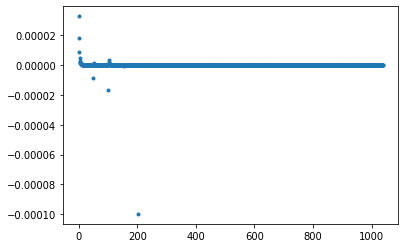

In [23]:
def abs_residual(q):
  ''' Compute absolute residual'''
  vec_res = (scipy.sparse.eye(self.num_dof) + dt * (L + M)) @ q - RHS
  return np.linalg.norm(vec_res.squeeze())

def sca_residual(q):
  ''' Compute scaled residual'''
  vec_res = (scipy.sparse.eye(self.num_dof) + dt * (L + M)) @ q - RHS
  return np.linalg.norm((_scaling_mat_inv @ vec_res).squeeze())

print(f"2-norm residual: {abs_residual(q1s)}, {abs_residual(q1)}, {abs_residual(q2)}")
print(f"scaled-norm residual: {sca_residual(q1s)}, {sca_residual(q1)}, {sca_residual(q2)}")

plt.plot(_scaling_mat_inv @ ((scipy.sparse.eye(self.num_dof) + dt * (L + M)) @ q - RHS), '.')

In [24]:
print(f"Shapes: {q1.shape}, {q1s.shape}, {q2.shape}")
np.linalg.norm(q1-q1s), np.linalg.norm(q1s-q2), np.linalg.norm(q1-q2)
# plt.semilogy(q1s, 'o')
# plt.semilogy(q1, '.')
# plt.semilogy(q2, '.')


Shapes: (1040, 1), (1040, 1), (1040, 1)


(0.0008802615418613255, 0.0010918300671385692, 0.0005459150335692846)

In [25]:
''' Solve scaled system in all three methods '''

# Inverse desired: inv(scipy.sparse.eye(global_sys.num_dof) + dt * L + dt * M)
dt = t_vec[1] - t_vec[0]
# Additive separation of LHS matrix
static_factor = scipy.sparse.eye(global_sys.num_dof) + dt * L
dynamic_factor = dt * M
# Invert static part sparsesly
static_inv = scipy.sparse.linalg.inv(scipy.sparse.csc_matrix(static_factor))

In [26]:
# Reconstruct mass transfer stencil in outer product form
# Generate tuples (i,j,mass_rate_scaling)
tups = global_sys.compute_mass_vecs(q_out[-1,:])
N_edges = len(tups)
M_recons = np.zeros((global_sys.num_dof, global_sys.num_dof,))
U = np.zeros((global_sys.num_dof, N_edges))
V = np.zeros((N_edges, global_sys.num_dof))
for edge_idx, (i, j, mdot_scaling) in enumerate(tups):
  U[global_sys.data_slice_global(i, "mass"), edge_idx] = 1.0
  U[global_sys.data_slice_global(j, "mass"), edge_idx] = -1.0
  V[edge_idx, :] = mdot_scaling * global_sys.M_vecs[(i,j)]
M_recons = np.einsum("ir, rj -> ij", U, V)

L, M, f = global_sys.assemble_global_LMf(q_out[-1,:])
print("Norm of difference between M and reconstructed U@V:")
print(f"{np.linalg.norm(M - M_recons)}")

Norm of difference between M and reconstructed U@V:
0.0


Sparsity pattern of explicit inverse of static part of system matrix:


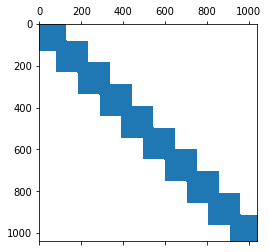

In [27]:
# Inverse desired: inv(scipy.sparse.eye(global_sys.num_dof) + dt * L + dt * M)
dt = t_vec[1] - t_vec[0]
# Additive separation of LHS matrix
static_factor = scipy.sparse.eye(global_sys.num_dof) + dt * L
dynamic_factor = dt * M
# Invert static part sparsesly
static_inv = scipy.sparse.linalg.inv(scipy.sparse.csc_matrix(static_factor))
plt.spy(static_inv)
print("Sparsity pattern of explicit inverse of static part of system matrix:")

In [28]:
''' Sherman-Morrison:
inv(A + UV') ==
  Ainv - Ainv @ U @ inv(I + V' Ainv U) @ V^T @ Ainv
'''

def full_solve(f):
  return scipy.sparse.linalg.spsolve(static_factor + dynamic_factor, f)

def low_rank_update(f, U, V):
  _t1 = static_inv @ f
  _t2 = V @ _t1
  _t2 = scipy.linalg.solve(np.eye(N_edges) + dt * V @ (static_inv @ U) , _t2)
  return (_t1 - dt * static_inv @ (U @ _t2)).ravel()

rel_err = np.linalg.norm(low_rank_update(f, U, V) - full_solve(f)) / np.linalg.norm(full_solve(f))

print("We compute from low rank update u1, and from the full inverse u0.")
print(f"The error (||u1 - u0|| / ||u0||) is {rel_err}")

We compute from low rank update u1, and from the full inverse u0.
The error (||u1 - u0|| / ||u0||) is 0.0001749358877077763


In [29]:
# %pip install line_profiler
%load_ext line_profiler
%lprun -f global_sys.simulation global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

Timer unit: 1e-07 s

Total time: 1.15899 s
File: c:\Code\magma-network\cnetwork.py
Function: simulation at line 1063

Line #      Hits         Time  Per Hit   % Time  Line Contents
  1063                                             def simulation(self, q0, t_vec, f_inject:callable, f_erupt:callable, method_order=1,
  1064                                                            solve_full_matrix = False, check_residual=False):
  1065                                               ''' Timestepping using a partially implicit scheme. Opening of network edges
  1066                                               are done explicitly, with a "limiter" for eruption. '''
  1067                                           
  1068                                               # Start q with initial condition
  1069         1        116.0    116.0      0.0      q = q0.copy()
  1070                                               # Allocate full output storage
  1071         1        172.0    172.0   